# Guided Numeric Exploration — Multi-Condition Transcriptomic DEG Table
_WT vs OX at 0h: differential expression, FDR, and regulation direction_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [willianoliveiragibin/multi-condition-transcriptomic](https://www.kaggle.com/datasets/willianoliveiragibin/multi-condition-transcriptomic)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Expression & DEG Stats](#Univariate)** <br>
**4. [Volcano and MA Views](#Volcano)** <br>
**5. [Count vs FPKM Concordance](#Concordance)** <br>
**6. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
The file is a **gene-level differential expression table** (430 rows) contrasting `WT0h` vs `OX0h` with raw counts, FPKM, `log2FC`, `FDR`, and a `regulated` label (`up`/`down`).

**Data-card caveat:** the Kaggle description references an Arabidopsis AGL22 drought time-series GRN study. The CSV itself is a two-condition 0h DEG export, not a multi-time-point matrix. This notebook analyzes the table as provided and flags that mismatch.

I will not impute FDR or fold-change; volcano and cutoff sensitivity stay on parsed numeric values.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances, PCA), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
CSV_BASENAME = "Multi-condition-transcriptomic new.csv"
KAGGLE_SLUG = "willianoliveiragibin/multi-condition-transcriptomic"
NUM_COLS = ["WT0h_Count", "OX0h_Count", "WT0h_FPKM", "OX0h_FPKM", "FDR", "log2FC"]


def parse_eu_number(x) -> float:
    if pd.isna(x):
        raise AssertionError("unexpected null in numeric DEG cell")
    if isinstance(x, (int, float, np.floating, np.integer)):
        return float(x)
    s = str(x).strip().replace(" ", "").replace(",", ".")
    return float(s)


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(CSV_BASENAME):
            return p
        hits = list(kaggle_root.rglob("*transcriptomic*.csv"))
        assert hits, "no transcriptomic csv under /kaggle/input"
        return hits[0]
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    hits = list(root.rglob(CSV_BASENAME))
    assert hits, f"expected {CSV_BASENAME} under {root}"
    return hits[0]


csv_path = resolve_csv_path()
print("CSV:", csv_path)
raw = pd.read_csv(csv_path, low_memory=False)
assert len(raw) == 430, f"expected 430 genes, got {len(raw)}"
for c in NUM_COLS + ["regulated", "#ID"]:
    assert c in raw.columns, f"missing column {c}"

df = raw.copy()
for c in NUM_COLS:
    df[c] = df[c].map(parse_eu_number)
assert df["regulated"].isin(["up", "down"]).all()
assert (df["FDR"] >= 0).all() and (df["FDR"] <= 1).all()
df["neglog10_fdr"] = -np.log10(df["FDR"].clip(lower=1e-300))
df["mean_fpkm"] = df[["WT0h_FPKM", "OX0h_FPKM"]].mean(axis=1)
df["log_mean_fpkm"] = np.log10(df["mean_fpkm"].clip(lower=1e-12))

unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
print("Missing Values:", df.isnull().sum().sum())
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("regulated:", df["regulated"].value_counts().to_dict())


  0%|          | 0.00/12.8k [00:00<?, ?B/s]

100%|██████████| 12.8k/12.8k [00:00<00:00, 4.09MB/s]

Extracting files...


CSV: /Users/nicapotato/.cache/kagglehub/datasets/willianoliveiragibin/multi-condition-transcriptomic/versions/1/Multi-condition-transcriptomic new.csv
Missing Values: 0
Dataframe Dimension: 430 Rows, 11 Columns
regulated: {'up': 277, 'down': 153}


**Code Explanation and Reasoning:** <br>
EU decimals and scientific notation are parsed into floats; FDR is clipped only for the −log10 transform display helper, not replaced in the table. Asserts lock gene count and `up`/`down` labels.


In [3]:
df.sample(5, random_state=7)


,#ID,WT0h_Count,OX0h_Count,WT0h_FPKM,OX0h_FPKM,FDR,log2FC,regulated,neglog10_fdr,mean_fpkm,log_mean_fpkm
118,AT3G54500,251.0,541.0,5.599645,11.394786,3.790000e-14,1.112042,up,13.421361,8.497215,0.929277
237,AT1G68850,609.0,951.0,27.794700,42.238100,1.520000e-06,0.649639,up,5.818156,35.016400,1.544271
220,AT1G60270,143.0,230.0,5.521279,8.132060,3.868633e-02,0.688877,up,1.412442,6.826669,0.834209
278,AT3G28910,425.0,281.0,18.003800,10.985000,9.837909e-03,-0.587336,down,2.007097,14.494400,1.161200
277,AT3G61490,343.0,227.0,11.102330,7.445820,3.772591e-02,-0.585504,down,1.423360,9.274075,0.967271


In [4]:
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]))
df[NUM_COLS].describe().T


,Column,Unique,Null
0,#ID,430,0
1,WT0h_Count,325,0
2,OX0h_Count,366,0
3,WT0h_FPKM,429,0
4,OX0h_FPKM,430,0
5,FDR,347,0
6,log2FC,430,0
7,regulated,2,0
8,neglog10_fdr,347,0
9,mean_fpkm,430,0


,count,mean,std,min,25%,50%,75%,max
WT0h_Count,430.0,2131.758140,24150.534473,0.000000,8.900000e+01,2.715000e+02,825.000000,498230.000000
OX0h_Count,430.0,1567.927907,11651.823395,0.000000,1.330000e+02,3.340000e+02,958.500000,238780.000000
WT0h_FPKM,430.0,52.515288,186.743068,0.000000,3.941993e+00,1.270815e+01,32.369650,3156.740000
OX0h_FPKM,430.0,51.987911,133.625329,0.000000,5.865113e+00,1.569470e+01,41.737275,1648.338000
FDR,430.0,0.003317,0.009193,0.000000,4.630000e-13,2.260000e-07,0.000514,0.049253
log2FC,430.0,0.386145,1.611402,-5.489025,-6.848647e-01,7.123702e-01,1.142083,6.361511


**Interpretation** <br>
More genes are labeled `up` than `down` in this export. Counts and FPKM can disagree in rank for low-expression genes; FDR and log2FC are the DEG decision surface for volcano analysis.


# **3. Univariate Expression & DEG Stats:** <a id="Univariate"></a>


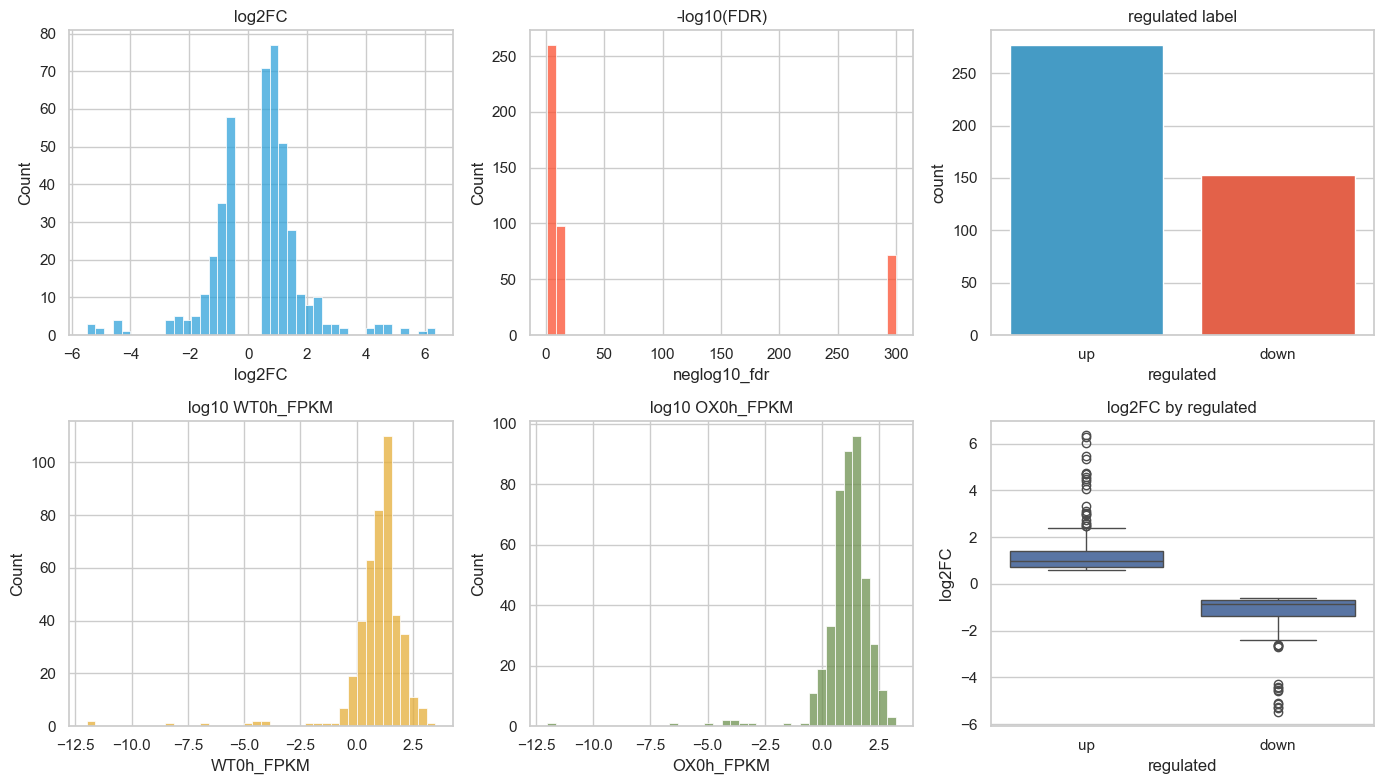

FDR <= 0.05: 430 genes (100.0%)
FDR <= 0.01: 385 genes (89.5%)
FDR <= 0.001: 336 genes (78.1%)


In [5]:
f, ax = plt.subplots(2, 3, figsize=(14, 8))
sns.histplot(df["log2FC"], bins=40, ax=ax[0, 0], color="#30a2da")
ax[0, 0].set_title("log2FC")
sns.histplot(df["neglog10_fdr"], bins=40, ax=ax[0, 1], color="#fc4f30")
ax[0, 1].set_title("-log10(FDR)")
sns.countplot(x=df["regulated"], order=["up", "down"], ax=ax[0, 2], palette=["#30a2da", "#fc4f30"])
ax[0, 2].set_title("regulated label")
sns.histplot(np.log10(df["WT0h_FPKM"].clip(lower=1e-12)), bins=40, ax=ax[1, 0], color="#e5ae38")
ax[1, 0].set_title("log10 WT0h_FPKM")
sns.histplot(np.log10(df["OX0h_FPKM"].clip(lower=1e-12)), bins=40, ax=ax[1, 1], color="#6d904f")
ax[1, 1].set_title("log10 OX0h_FPKM")
sns.boxplot(data=df, x="regulated", y="log2FC", order=["up", "down"], ax=ax[1, 2])
ax[1, 2].set_title("log2FC by regulated")
plt.tight_layout()
plt.show()

for cut in [0.05, 0.01, 0.001]:
    n = int((df["FDR"] <= cut).sum())
    print(f"FDR <= {cut}: {n} genes ({n/len(df):.1%})")


**How to Interpret:** <br>
`regulated` should align with the sign of `log2FC` (up positive, down negative) if the export is consistent. FDR cutoff counts show how sensitive a 'significant DEG' list is to threshold choice.


# **4. Volcano and MA Views:** <a id="Volcano"></a>


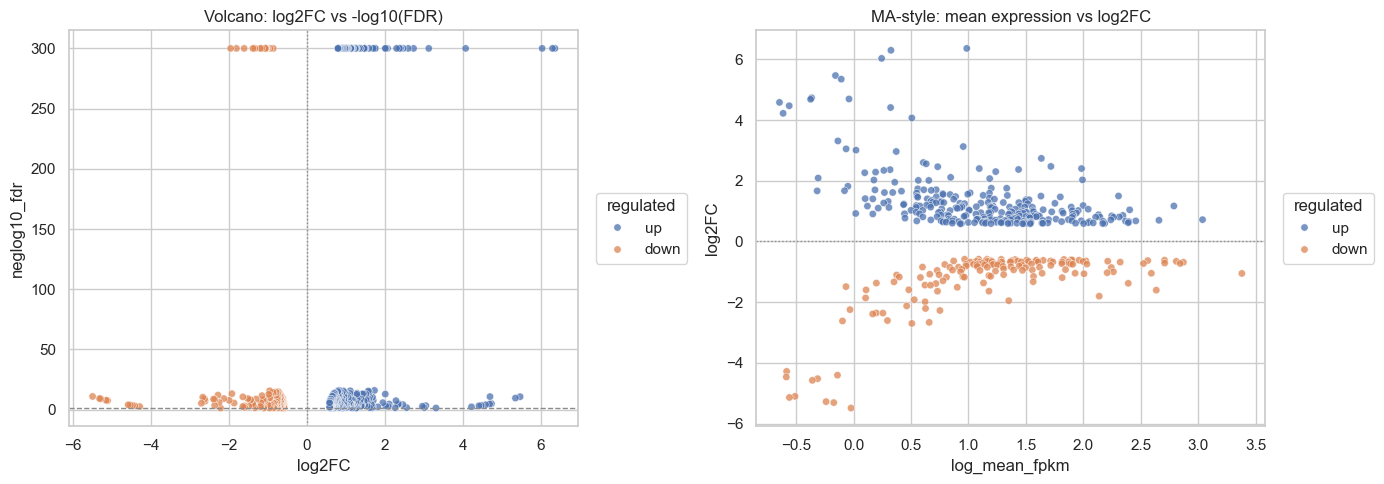

,#ID,log2FC,FDR,regulated,WT0h_FPKM,OX0h_FPKM
0,Arab_newGene_9,6.361511,0.000000e+00,up,1.327120e-02,1.933580e+01
1,AT3G18650,6.298178,0.000000e+00,up,0.000000e+00,4.233120e+00
2,AT2G30615,6.032333,0.000000e+00,up,1.370000e-07,3.512530e+00
429,Arab_newGene_130,-5.489025,1.150000e-11,down,1.902259e+00,0.000000e+00
3,AT5G41170,5.467974,1.730000e-11,up,6.470000e-09,1.392300e+00
4,AT1G14190,5.348012,2.450000e-10,up,4.580000e-05,1.563310e+00
428,AT2G41080,-5.308974,5.960000e-10,down,1.345670e+00,3.630000e-07
427,AT2G41890,-5.276653,1.150000e-09,down,1.152950e+00,7.980000e-05
426,AT3G04980,-5.139603,1.630000e-08,down,5.519490e-01,1.105650e-03
425,AT5G27240,-5.103205,3.170000e-08,down,6.181460e-01,1.646820e-04


In [6]:
f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=df, x="log2FC", y="neglog10_fdr", hue="regulated",
    hue_order=["up", "down"], ax=ax[0], alpha=0.75, s=28,
)
ax[0].axhline(-np.log10(0.05), ls="--", color="#8b8b8b", lw=1)
ax[0].axvline(0, ls=":", color="#8b8b8b", lw=1)
ax[0].set_title("Volcano: log2FC vs -log10(FDR)")
ax[0].legend(title="regulated", bbox_to_anchor=(1.02, 0.5), loc="center left")

sns.scatterplot(
    data=df, x="log_mean_fpkm", y="log2FC", hue="regulated",
    hue_order=["up", "down"], ax=ax[1], alpha=0.75, s=28,
)
ax[1].axhline(0, ls=":", color="#8b8b8b", lw=1)
ax[1].set_title("MA-style: mean expression vs log2FC")
ax[1].legend(title="regulated", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()

# Extreme genes
top = df.reindex(df["log2FC"].abs().sort_values(ascending=False).index).head(10)
display(top[["#ID", "log2FC", "FDR", "regulated", "WT0h_FPKM", "OX0h_FPKM"]])


**How to Interpret:** <br>
Volcano points high and far from x=0 are strong DEGs. The dashed line marks FDR=0.05. The MA-style panel checks whether large fold-changes concentrate in low-expression genes (more fragile) or span the expression range.


# **5. Count vs FPKM Concordance:** <a id="Concordance"></a>


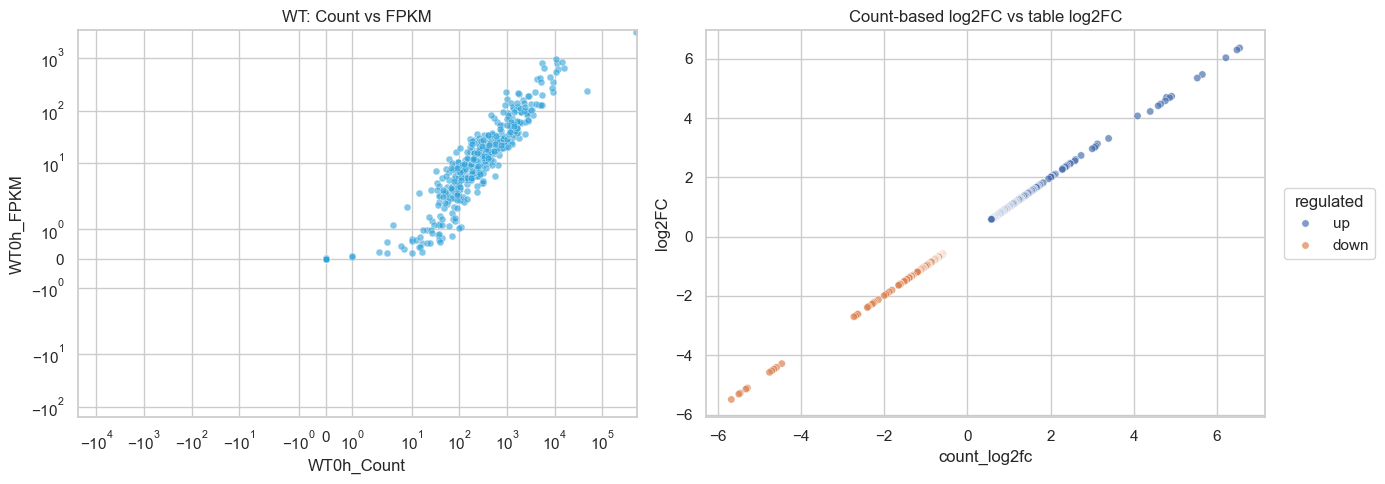

Pearson r(count_log2fc, log2FC): 1.0
Sign agreement regulated vs log2FC: 1.0


In [7]:
df["count_log2fc"] = np.log2((df["OX0h_Count"] + 1) / (df["WT0h_Count"] + 1))
f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="WT0h_Count", y="WT0h_FPKM", ax=ax[0], alpha=0.6, color="#30a2da", s=25)
ax[0].set_xscale("symlog")
ax[0].set_yscale("symlog")
ax[0].set_title("WT: Count vs FPKM")
sns.scatterplot(data=df, x="count_log2fc", y="log2FC", hue="regulated",
                hue_order=["up", "down"], ax=ax[1], alpha=0.7, s=28)
ax[1].set_title("Count-based log2FC vs table log2FC")
ax[1].legend(title="regulated", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()
print("Pearson r(count_log2fc, log2FC):", round(df["count_log2fc"].corr(df["log2FC"]), 3))
print("Sign agreement regulated vs log2FC:",
      float(((df["regulated"] == "up") == (df["log2FC"] > 0)).mean()))


**How to Interpret:** <br>
If table `log2FC` was derived from FPKM (or a GLM), it need not equal a naive count ratio, but the sign should usually agree with `regulated`. Large disagreements flag export quirks.


# **6. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A 430-gene DEG export for WT0h vs OX0h with counts, FPKM, FDR, log2FC, and up/down labels — not the multi-time-point drought GRN implied by the data card.

**Working takeaways:** <br>
- Parse EU/scientific strings before volcano work.
- Up/down imbalance and FDR cutoffs reshape any 'top gene' list.
- Cross-check count ratios against published log2FC for export integrity.

**Open follow-ups:** <br>
- Pathway enrichment on ID space if IDs map to a known genome.
- Recover the full time-series if the card study is the real target.
